In [1]:
%load_ext autoreload
%autoreload 2

import sys
sys.path.append('..')

import numpy as np
import pandas as pd
import torch
from tqdm import tqdm

%matplotlib inline
import matplotlib.pyplot as plt


C:\Users\xunathan\AppData\Local\Temp\ipykernel_20796\2492266573.py:8: DeprecationWarning: 
Pyarrow will become a required dependency of pandas in the next major release of pandas (pandas 3.0),
(to allow more performant data types, such as the Arrow string type, and better interoperability with other libraries)
but was not found to be installed on your system.
If this would cause problems for you,
please provide us feedback at https://github.com/pandas-dev/pandas/issues/54466
        
  import pandas as pd


In [212]:
hsic_df = pd.read_csv('../exp/eval/hsic/stats.csv')
c2st_df = pd.read_csv('../exp/eval/c2st/stats.csv')


In [141]:
def filter_nsamples_vs_power(model: str, dataset: str):
    if model=='c2st':
        data = c2st_df[(c2st_df['classifier']=='mlp_small')&(c2st_df['dataset']==dataset)]
    elif model=='deep':
        data = hsic_df[(hsic_df['kernel']=='mlp_small')&(hsic_df['dataset']==dataset)]
    elif model in ['median', 'bandwidth']:
        data = hsic_df[(hsic_df['kernel']==model)&(hsic_df['dataset']==dataset)]
    return data['n-samples'].to_numpy(), data['power'].to_numpy()


nsamples_vs_power = dict()
for dataset in ['HDGM-4', 'HDGM-8', 'HDGM-10', 'HDGM-20', 'HDGM-30', 'HDGM-40', 'HDGM-50']:
    nsamples_vs_power[dataset] = {
        'median': filter_nsamples_vs_power(model='median', dataset=dataset),
        'bandwidth': filter_nsamples_vs_power(model='bandwidth', dataset=dataset),
        'deep': filter_nsamples_vs_power(model='deep', dataset=dataset),
        'c2st': filter_nsamples_vs_power(model='c2st', dataset=dataset),
    }

nsamples_vs_power['HDGM-40']

{'median': (array([ 100,  200,  500, 1000, 2000, 4000], dtype=int64),
  array([0.03, 0.08, 0.06, 0.03, 0.03, 0.03])),
 'bandwidth': (array([ 100,  200,  500, 1000, 2000, 4000], dtype=int64),
  array([0.02, 0.07, 0.04, 0.04, 0.04, 0.03])),
 'deep': (array([ 100,  200,  500, 1000, 2000, 4000], dtype=int64),
  array([0.45, 0.73, 0.99, 1.  , 1.  , 1.  ])),
 'c2st': (array([ 100,  200,  500, 1000, 2000, 4000], dtype=int64),
  array([0.34, 0.37, 0.69, 0.86, 0.97, 1.  ]))}

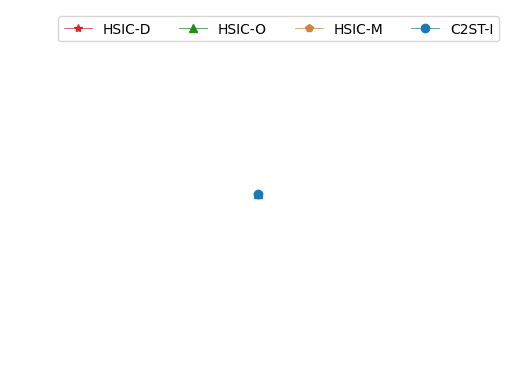

In [142]:
# plot just the legend
plt.plot(0, 0, '*-', linewidth=0.5, color='tab:red')
plt.plot(0, 0, '^-', linewidth=0.5, color='forestgreen')
plt.plot(0, 0, 'p-', linewidth=0.5, color='peru')
plt.plot(0, 0, 'o-', linewidth=0.5, color='tab:blue')
plt.legend(['HSIC-D', 'HSIC-O', 'HSIC-M', 'C2ST-I'], ncol=4)

plt.axis(False)
plt.savefig(f"toy_plots/legend.pdf", format="pdf", bbox_inches="tight")



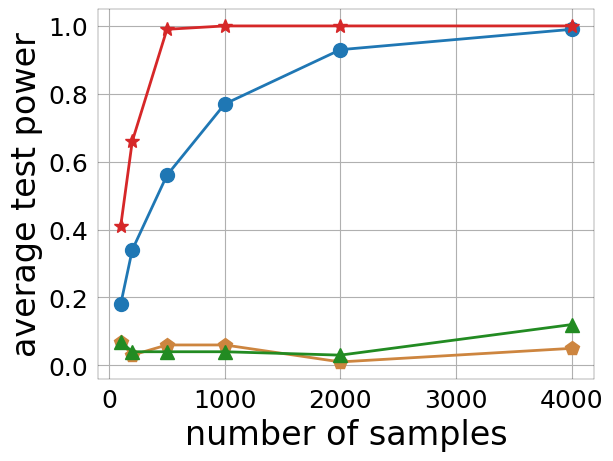

In [205]:
# power vs samples for fixed dimension
DATASET = 'HDGM-50'

LINEWIDTH = 2
MARKERSIZE = 10
plt.plot(*nsamples_vs_power[DATASET]['median'], 'p-', linewidth=LINEWIDTH, markersize=MARKERSIZE, color='peru')
plt.plot(*nsamples_vs_power[DATASET]['bandwidth'], '^-', linewidth=LINEWIDTH, markersize=MARKERSIZE, color='forestgreen')
plt.plot(*nsamples_vs_power[DATASET]['c2st'], 'o-', linewidth=LINEWIDTH, markersize=MARKERSIZE, color='tab:blue')
plt.plot(*nsamples_vs_power[DATASET]['deep'], '*-', linewidth=LINEWIDTH, markersize=MARKERSIZE, color='tab:red')
#plt.legend(['HSIC-M', 'HSIC-O', 'HSIC-D'], ncol=1, fontsize=18)
plt.grid()
#plt.title(DATASET)
plt.xlabel("number of samples", fontsize=24)
plt.ylabel("average test power", fontsize=24)
#plt.xlim(xmin=90)


plt.rcParams['axes.linewidth'] = 0.2
plt.tick_params(left=False, labelsize=18)
plt.tick_params(bottom=False, labelsize=18)
plt.gca().xaxis.set_major_locator(plt.MultipleLocator(1000))

plt.savefig(f"toy_plots/nsamples_vs_power_{DATASET.replace('-','')}.pdf", format="pdf", bbox_inches="tight")



In [158]:

def filter_dim_vs_power(model: str, n_samples: int):
    if model=='c2st':
        data = c2st_df[(c2st_df['classifier']=='mlp_small')&(c2st_df['n-samples']==n_samples)]
    elif model=='deep':
        data = hsic_df[(hsic_df['kernel']=='mlp_small')&(hsic_df['n-samples']==n_samples)]
    elif model in ['median', 'bandwidth']:
        data = hsic_df[(hsic_df['kernel']==model)&(hsic_df['n-samples']==n_samples)]
    return data['dataset'].apply(lambda s: int(s.split('-')[-1])/2).to_numpy(), data['power'].to_numpy()


dim_vs_power = dict()
for n_samples in [100, 500, 1000, 2000, 4000]:
    dim_vs_power[n_samples] = {
        'median': filter_dim_vs_power(model='median', n_samples=n_samples),
        'bandwidth': filter_dim_vs_power(model='bandwidth', n_samples=n_samples),
        'deep': filter_dim_vs_power(model='deep', n_samples=n_samples),
        'c2st': filter_dim_vs_power(model='c2st', n_samples=n_samples),
    }

dim_vs_power[100]

{'median': (array([ 2.,  4.,  5., 10., 15., 20., 25.]),
  array([0.13, 0.  , 0.04, 0.03, 0.02, 0.03, 0.07])),
 'bandwidth': (array([ 2.,  4.,  5., 10., 15., 20., 25.]),
  array([0.11, 0.04, 0.05, 0.06, 0.04, 0.02, 0.07])),
 'deep': (array([ 2.,  4.,  5., 10., 15., 20., 25.]),
  array([0.6 , 0.41, 0.52, 0.46, 0.46, 0.45, 0.41])),
 'c2st': (array([ 2.,  4.,  5., 10., 15., 20., 25.]),
  array([0.27, 0.31, 0.25, 0.27, 0.28, 0.34, 0.18]))}

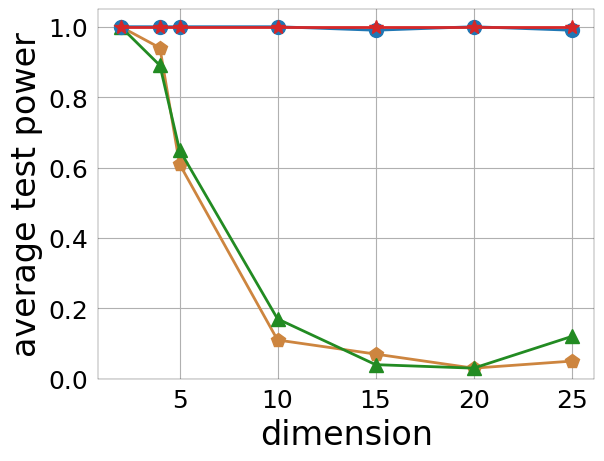

In [210]:
# power vs dimension for fixed number of samples
N_SAMPLES = 4000

LINEWIDTH = 2
MARKERSIZE = 10
plt.plot(*dim_vs_power[N_SAMPLES]['median'], 'p-', linewidth=LINEWIDTH, markersize=MARKERSIZE, color='peru')
plt.plot(*dim_vs_power[N_SAMPLES]['bandwidth'], '^-', linewidth=LINEWIDTH, markersize=MARKERSIZE, color='forestgreen')
plt.plot(*dim_vs_power[N_SAMPLES]['c2st'], 'o-', linewidth=LINEWIDTH, markersize=MARKERSIZE, color='tab:blue')
plt.plot(*dim_vs_power[N_SAMPLES]['deep'], '*-', linewidth=LINEWIDTH, markersize=MARKERSIZE, color='tab:red')
#plt.legend(['median', 'bandwidth', 'c2st', 'deepkernel'])
plt.grid()
plt.ylim(0, 1.05)
#plt.title(f'n_samples={N_SAMPLES}')
plt.xlabel("dimension", fontsize=24)
plt.ylabel("average test power", fontsize=24)

plt.rcParams['axes.linewidth'] = 0.2
plt.tick_params(left=False, labelsize=18)
plt.tick_params(bottom=False, labelsize=18)
#plt.gca().xaxis.set_major_locator(plt.MultipleLocator(1000))

plt.savefig(f"toy_plots/dim_vs_power_n{N_SAMPLES}.pdf", format="pdf", bbox_inches="tight")


slice(None, None, None)
xy.shape: torch.Size([10000, 4])


(-4.0, 4.0)

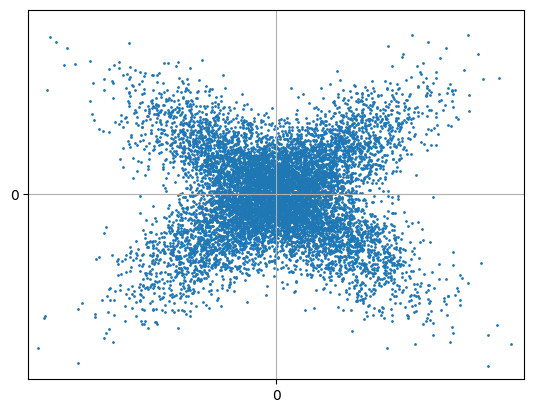

In [9]:
import sys
sys.path.append('..')

import numpy as np
import pandas as pd
import torch
from tqdm import tqdm

%matplotlib inline
import matplotlib.pyplot as plt

from data.toy import HDGM


hdgm = HDGM(10000, dim=4)
x,y = hdgm[:]

fig, ax = plt.subplots()
plt.scatter(x[:,0],y[:,1], s=1)
#plt.grid()
ax.set_xticks([0.0], minor=False)
ax.set_yticks([0.0], minor=False)
ax.xaxis.grid(True, which='major')
ax.yaxis.grid(True, which='major')
#ax.set_aspect('equal')

plt.xlim(-4., 4.)
plt.ylim(-4., 4.)
#plt.show()

#plt.savefig(f"toy_plots/hdgm_samples.png", format="png", bbox_inches="tight")
